# Style-Weighted vs Plain — sample comparison (Gojira & Tool)

Lightweight A/B per artist: read the cached `<artist>_lora_r8` and
`<artist>_lora_r8_sw` results (generated by `evaluate.py`), classify means, and
eyeball the text. Attribution is the headline metric; the distinctive-token
counts below quantify the lexical-richness side.

SW's effect is **sign-dependent**: it lowers attribution for Gojira (already
saturated) but raises it for Tool (plain Tool was underfit/bimodal).

In [1]:
import json
import pandas as pd

from generation.model import load_tokenizer
from config import RESULTS_DIR, Adapter

# Display-only: adapters are scored by evaluate.py (run_adapters).
# Run `uv run python evaluate.py` first. Only the tokenizer is needed here
# (for the distinctive-token counts), not the base model or classifier.
tok = load_tokenizer()
CACHE_DIR = RESULTS_DIR / "adapters"
ARTISTS = ["Gojira", "Tool", "Death", "Mastodon", "Opeth"]

# Per-artist distinctive-token MEASUREMENT config. Symmetric n=40 + stopword
# drop for all (cleanest/comparable). Token-level TF-IDF cleanly captures
# concrete-noun styles (Gojira); register-based styles (Tool) are diluted by
# function words, hence the stopword drop. NOTE: across-artist `types`
# magnitudes are only loosely comparable; the robust signal is plain-vs-sw
# WITHIN each artist.
DISTINCTIVE_CFG = {a: dict(n=40, drop_stopwords=True) for a in ARTISTS}

In [2]:
def load_run(artist, sw):
    ad = Adapter(artist, "lora", 8, sw=sw)
    f = CACHE_DIR / ad.result_relpath
    if not f.exists():
        print(f"missing {ad.name} -- run `uv run python evaluate.py`")
        return None
    hit = json.load(open(f))
    return hit["samples"], pd.DataFrame(hit["df"])

# runs[artist] = {"plain": (samples, df), "sw": (samples, df)}
runs = {}
for artist in ARTISTS:
    runs[artist] = {}
    for sw, key in [(False, "plain"), (True, "sw")]:
        r = load_run(artist, sw)
        if r is None:
            continue
        runs[artist][key] = r
        df = r[1]
        print(f"{artist:7} {key:5}: mean {artist} attr {df[artist].mean():.3f}  (std {df[artist].std():.3f})")

Gojira  plain: mean Gojira attr 0.961  (std 0.032)
Gojira  sw   : mean Gojira attr 0.630  (std 0.337)
Tool    plain: mean Tool attr 0.746  (std 0.294)
Tool    sw   : mean Tool attr 0.912  (std 0.133)
Death   plain: mean Death attr 0.973  (std 0.028)
Death   sw   : mean Death attr 0.943  (std 0.087)
Mastodon plain: mean Mastodon attr 0.517  (std 0.378)
Mastodon sw   : mean Mastodon attr 0.718  (std 0.343)
Opeth   plain: mean Opeth attr 0.947  (std 0.072)
Opeth   sw   : mean Opeth attr 0.834  (std 0.290)


In [3]:
# Side-by-side text, per artist
for artist in ARTISTS:
    pair = runs.get(artist, {})
    if "plain" not in pair or "sw" not in pair:
        continue
    plain_s, sw_s = pair["plain"][0], pair["sw"][0]
    n = min(len(plain_s), len(sw_s))
    print(f"\n{'='*20} {artist} {'='*20}")
    for i in range(n):
        print(f"\n########## {artist} SAMPLE {i + 1} ##########")
        print(f"\n----- plain -----\n{plain_s[i]}")
        print(f"\n----- sw -----\n{sw_s[i]}")


==================== Gojira ====================

########## Gojira SAMPLE 1 ##########

----- plain -----
I took a boat across the ocean
And I sail away, sailing home
On an open sea that is so deep
I'm falling into my dreams



And yet we all stand upon solid ground
Nowhere else to go and belong
We live in this world of ours, no other place
No one can tell us what to do
A thousand words at last are spoken
This vision is about to die
But now it comes alive when faced with reality
You will see you cannot face the truth
The end has come for good
Ashes to ashes ...


All along I have been dreaming
Of a different time and place
Some day on higher grounds I will find myself
And I'll overcome all obstacles
Until then I am going strong



It may take me hundreds of years
To discover who I am truly
Yet another step forward to reach the point
Where I will understand what happened
In this life there's nothing left to learn
For now, let me be where I want to be

----- sw -----
I'm dying
No, I ca

In [4]:
# Summary: per-adapter mean attribution across all artists
cols = {f"{artist} {key}": df.mean()
        for artist in ARTISTS for key, (s, df) in runs.get(artist, {}).items()}
summary = pd.DataFrame(cols)
summary

,Gojira plain,Gojira sw,Tool plain,Tool sw,Death plain,Death sw,Mastodon plain,Mastodon sw,Opeth plain,Opeth sw
Death,0.008701,0.077640,0.007004,0.004269,0.973348,0.943160,0.009954,0.078636,0.017138,0.036549
Gojira,0.961054,0.629578,0.093968,0.050746,0.013752,0.024686,0.198995,0.076883,0.019077,0.007671
Mastodon,0.013693,0.064701,0.079259,0.028118,0.003177,0.004824,0.516702,0.717927,0.011760,0.032409
Opeth,0.011662,0.005279,0.074087,0.005176,0.005762,0.007795,0.268721,0.007504,0.947245,0.834081
Tool,0.004890,0.222802,0.745682,0.911691,0.003962,0.019534,0.005629,0.119051,0.004780,0.089290


## Distinctive-token count

Turns "I liked SW more" into a number: count how many of Gojira's top
distinctive tokens (the ones SW up-weights) actually appear in each adapter's
output. If SW lands more, that backs the qualitative preference even though the
attribution classifier scored it lower.

In [5]:
from config import DATA_DIR
from generation.style_loss import build_style_weights
from evaluation.metrics import distinctive_tokens

train_df = pd.read_csv(DATA_DIR / "train.csv")  # text_col="clean", artist_col="artist" by default

# Per-artist top distinctive tokens, using each artist's measurement config.
toks = {}
for artist in ARTISTS:
    w = build_style_weights(artist, train_df, tok)
    cfg = DISTINCTIVE_CFG[artist]
    toks[artist] = distinctive_tokens(w, tok, **cfg)
    print(f"{artist} ({len(toks[artist])} tokens, {cfg}):")
    print("  ", sorted(toks[artist]))

Gojira (33 tokens, {'n': 40, 'drop_stopwords': True}):
   ['attention', 'bag', 'boat', 'bow', 'children', 'code', 'create', 'cycle', 'dig', 'enter', 'fight', 'forces', 'ind', 'load', 'lock', 'low', 'new', 'point', 'positive', 'present', 'protect', 'render', 'round', 'shape', 'space', 'star', 'stars', 'structure', 'throw', 'trees', 'understand', 'understanding', 'ved']
Tool (31 tokens, {'n': 40, 'drop_stopwords': True}):
   ['adds', 'ately', 'bog', 'calling', 'cheat', 'dick', 'dumb', 'finger', 'fret', 'frightened', 'fuck', 'fucking', 'hey', 'information', 'jesus', 'learn', 'love', 'nard', 'phone', 'press', 'pushing', 'quarter', 'reminding', 'scared', 'shit', 'shoving', 'sober', 'swim', 'thinking', 'wanna', 'weather']
Death (36 tokens, {'n': 40, 'drop_stopwords': True}):
   ['ation', 'bloody', 'cor', 'corpse', 'corpses', 'cunt', 'deceased', 'den', 'drug', 'emotions', 'enger', 'escaping', 'evil', 'goblet', 'gore', 'grinder', 'icide', 'ificial', 'joining', 'justice', 'killer', 'knowing', '

In [6]:
from evaluation.metrics import token_occurrences

# Each artist's adapters matched against THAT artist's top-40 distinctive tokens.
for artist in ARTISTS:
    print(f"\n=== {artist} (top-40 {artist} tokens) ===")
    for key, (s, df) in runs.get(artist, {}).items():
        h = token_occurrences(s, toks[artist])
        print(f"  {key:5} {h} hits over {len(s)} samples  ({h / len(s):.1f}/sample)")


=== Gojira (top-40 Gojira tokens) ===
  plain 19 hits over 10 samples  (1.9/sample)
  sw    119 hits over 10 samples  (11.9/sample)

=== Tool (top-40 Tool tokens) ===
  plain 31 hits over 10 samples  (3.1/sample)
  sw    285 hits over 10 samples  (28.5/sample)

=== Death (top-40 Death tokens) ===
  plain 29 hits over 10 samples  (2.9/sample)
  sw    72 hits over 10 samples  (7.2/sample)

=== Mastodon (top-40 Mastodon tokens) ===
  plain 27 hits over 10 samples  (2.7/sample)
  sw    49 hits over 10 samples  (4.9/sample)

=== Opeth (top-40 Opeth tokens) ===
  plain 7 hits over 10 samples  (0.7/sample)
  sw    71 hits over 10 samples  (7.1/sample)


In [7]:
from evaluation.metrics import token_types

for artist in ARTISTS:
    print(f"\n=== {artist} ===")
    for key, (s, df) in runs.get(artist, {}).items():
        print(f"  {key:5} {token_types(s, toks[artist]):.1f} distinct tokens/sample")


=== Gojira ===
  plain 1.6 distinct tokens/sample
  sw    5.7 distinct tokens/sample

=== Tool ===
  plain 2.5 distinct tokens/sample
  sw    3.3 distinct tokens/sample

=== Death ===
  plain 1.7 distinct tokens/sample
  sw    1.5 distinct tokens/sample

=== Mastodon ===
  plain 2.0 distinct tokens/sample
  sw    3.3 distinct tokens/sample

=== Opeth ===
  plain 0.7 distinct tokens/sample
  sw    2.8 distinct tokens/sample


## Repetition / degeneration

`distinct-n` = unique n-grams / total n-grams, averaged over samples (lower = more
looping). This is the repetition-robust degeneration signal the attribution
classifier does *not* penalize — it should drop for SW (esp. Tool, whose
attribution gain is mostly repetition of a few markers, not richer vocabulary).

In [8]:
import statistics


def distinct_n(text, n):
    toks = text.lower().split()
    if len(toks) < n:
        return float("nan")
    grams = list(zip(*[toks[i:] for i in range(n)]))
    return len(set(grams)) / len(grams)


for artist in ARTISTS:
    print(f"\n=== {artist} ===")
    for key, (s, df) in runs.get(artist, {}).items():
        d1 = statistics.mean(distinct_n(t, 1) for t in s)
        d2 = statistics.mean(distinct_n(t, 2) for t in s)
        print(f"  {key:5} distinct-1 {d1:.2f}  distinct-2 {d2:.2f}  (lower = more repetition)")


=== Gojira ===
  plain distinct-1 0.68  distinct-2 0.96  (lower = more repetition)
  sw    distinct-1 0.53  distinct-2 0.71  (lower = more repetition)

=== Tool ===
  plain distinct-1 0.63  distinct-2 0.88  (lower = more repetition)
  sw    distinct-1 0.56  distinct-2 0.74  (lower = more repetition)

=== Death ===
  plain distinct-1 0.48  distinct-2 0.67  (lower = more repetition)
  sw    distinct-1 0.46  distinct-2 0.63  (lower = more repetition)

=== Mastodon ===
  plain distinct-1 0.68  distinct-2 0.90  (lower = more repetition)
  sw    distinct-1 0.56  distinct-2 0.70  (lower = more repetition)

=== Opeth ===
  plain distinct-1 0.69  distinct-2 0.92  (lower = more repetition)
  sw    distinct-1 0.55  distinct-2 0.71  (lower = more repetition)


## Adapter blending — Gojira-anchored SW blends

Reads `results/blends/<pair>/a<alpha>.json` (written by `evaluate.py::run_blends`).
α = weight on the Gojira-SW endpoint, shared across all pairs, so the curves are
directly comparable. Two figures:

- **plain vs SW on Gojira+Tool** — the crossover shifts (≈0.12 → ≈0.58): SW
  weakens the Gojira endpoint and strengthens Tool, flipping blend dominance.
- **4 Gojira-SW partners** — crossover skews toward the stronger partner
  endpoint (Death > Opeth > Tool > Mastodon); Mastodon's underfit endpoint
  lets Gojira take over earliest.

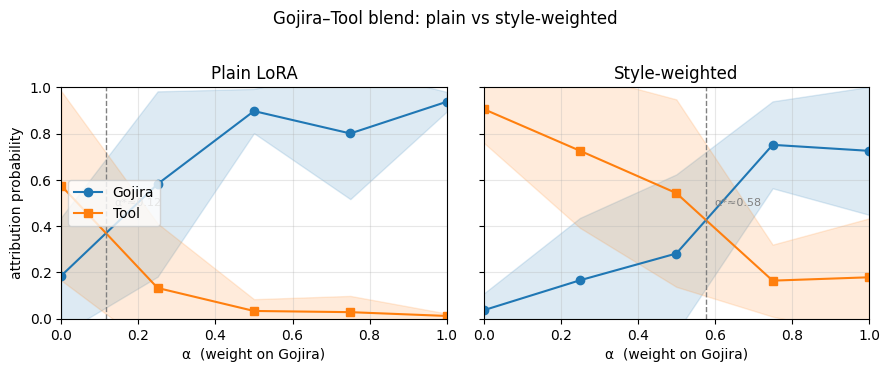

In [9]:
import numpy as np
import matplotlib.pyplot as plt

BLENDS_DIR = RESULTS_DIR / "blends"


def load_pair(pair):
    """alphas, list-of-dfs, and the two endpoint artist names for a blend pair."""
    files = sorted(BLENDS_DIR.glob(f"{pair}/a*.json"), key=lambda p: float(p.stem[1:]))
    alphas, dfs, sa, sb = [], [], None, None
    for f in files:
        j = json.load(open(f))
        alphas.append(j["alpha"]); dfs.append(pd.DataFrame(j["df"])); sa, sb = j["src_a"], j["src_b"]
    ea = next(a for a in ARTISTS if a.lower() == sa.split("_")[0])
    eb = next(a for a in ARTISTS if a.lower() == sb.split("_")[0])
    return np.array(alphas), dfs, ea, eb


def stat(dfs, artist):
    return (np.array([d[artist].mean() for d in dfs]),
            np.array([d[artist].std() for d in dfs]))


def crossover(alphas, g, p):
    """alpha where the Gojira curve overtakes the partner (linear interp)."""
    d = g - p
    for i in range(len(d) - 1):
        if d[i] <= 0 <= d[i + 1]:
            return alphas[i] - d[i] * (alphas[i + 1] - alphas[i]) / (d[i + 1] - d[i])
    return None


# --- Figure 1: plain vs SW on Gojira+Tool (the crossover shift) ---
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharey=True)
for ax, (pair, title) in zip(axes, [("gojira_tool", "Plain LoRA"),
                                     ("gojira_sw_tool_sw", "Style-weighted")]):
    alphas, dfs, ea, eb = load_pair(pair)
    gm, gs = stat(dfs, ea); pm, ps = stat(dfs, eb)
    ax.plot(alphas, gm, "-o", color="C0", label=ea)
    ax.fill_between(alphas, gm - gs, gm + gs, color="C0", alpha=0.15)
    ax.plot(alphas, pm, "-s", color="C1", label=eb)
    ax.fill_between(alphas, pm - ps, pm + ps, color="C1", alpha=0.15)
    xc = crossover(alphas, gm, pm)
    if xc is not None:
        ax.axvline(xc, ls="--", color="gray", lw=1)
        ax.annotate(f"α*≈{xc:.2f}", (xc, 0.5), xytext=(6, 0),
                    textcoords="offset points", va="center", fontsize=8, color="gray")
    ax.set_title(title); ax.set_xlabel(f"α  (weight on {ea})")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.grid(alpha=0.3)
axes[0].set_ylabel("attribution probability"); axes[0].legend(loc="center left")
fig.suptitle("Gojira–Tool blend: plain vs style-weighted", y=1.02)
fig.tight_layout()
fig.savefig("../report/figures/blend_sw_gojira_tool.pdf", bbox_inches="tight")
plt.show()

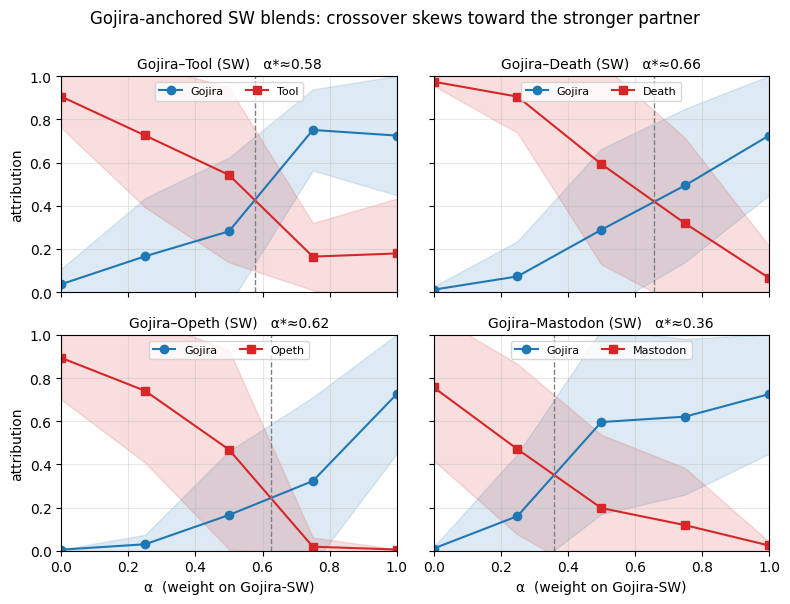

In [10]:
# --- Figure 2: the 4 Gojira-SW partners (crossover skews with partner strength) ---
sw_pairs = ["gojira_sw_tool_sw", "gojira_sw_death_sw",
            "gojira_sw_opeth_sw", "gojira_sw_mastodon_sw"]
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True)
for ax, pair in zip(axes.ravel(), sw_pairs):
    alphas, dfs, ea, eb = load_pair(pair)
    gm, gs = stat(dfs, ea); pm, ps = stat(dfs, eb)
    ax.plot(alphas, gm, "-o", color="C0", label=ea)
    ax.fill_between(alphas, gm - gs, gm + gs, color="C0", alpha=0.15)
    ax.plot(alphas, pm, "-s", color="C3", label=eb)
    ax.fill_between(alphas, pm - ps, pm + ps, color="C3", alpha=0.15)
    xc = crossover(alphas, gm, pm)
    ttl = f"Gojira–{eb} (SW)" + (f"   α*≈{xc:.2f}" if xc is not None else "")
    if xc is not None:
        ax.axvline(xc, ls="--", color="gray", lw=1)
    ax.set_title(ttl, fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.grid(alpha=0.3)
    ax.legend(loc="upper center", fontsize=8, ncol=2)
for ax in axes[-1]:
    ax.set_xlabel("α  (weight on Gojira-SW)")
for ax in axes[:, 0]:
    ax.set_ylabel("attribution")
fig.suptitle("Gojira-anchored SW blends: crossover skews toward the stronger partner", y=1.0)
fig.tight_layout()
fig.savefig("../report/figures/blend_sw_gojira_partners.pdf", bbox_inches="tight")
plt.show()